# Warm vs cold start — NAT $\alpha>0$ ladders at one bond dimension

Two ways to reach an $\alpha>0$ model exist in this project, and they are different
experiments at the same $(\text{arch}, \alpha)$:

| start | `config/descriptor` | how it was trained |
|---|---|---|
| **warm** | `nll_pretrained` | fine-tuned from the $\alpha=0$ checkpoint of the same arch |
| **cold** | `nll_cold` | trained from scratch, own HPO (or transferred HPs) |
| *base* | `nll` | $\alpha=0$, from scratch — **shared** by both ladders |

- **Part 1** rebuilds the study already in `figures/coldvswarm/` (commit `6cb04bc`): valid
  accuracy against valid generative NLL at each run's own early-stopped epoch, for every
  matched $(\text{bond dim}, \alpha)$ cell, from the cached W&B run table. Until now those
  figures had no code behind them.
- **Part 2** is the thorough comparison at **one bond dimension**, from the local analysis
  CSVs — so it sees the whole post-hoc metric set (robustness, likelihood purification,
  Gibbs purification, detection, joint attack), not just accuracy and generative loss.

| | |
|---|---|
| Part 1 data | `figures/coldvswarm/runs_valid_metrics.csv` (739 W&B runs, HPO + seed sweeps) |
| Part 2 data | `analysis/outputs/{DATASET}/nat/{EMBEDDING}/{ARCH}/**/evaluation_data.csv`, `gibbs_data.csv` |
| Part 1 output | `figures/coldvswarm/` (regenerated **in place**) |
| Part 2 output | `figures/coldvswarm/{EMBEDDING}/{ARCH}/` |

No checkpoint is loaded anywhere — `run_path` in these CSVs points at mathqi.

---
# §0  Setup

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/martin-lanigo/projects/bm4tc


In [2]:
import matplotlib

# Paper styling: Times New Roman via LaTeX (mathptmx). Requires a system LaTeX install
# (latex + dvipng); set USE_LATEX = False to fall back to matplotlib mathtext.
# NOTE: the committed Part 1 PNGs were made with the matplotlib default sans-serif face.
# Re-running Part 1 restyles them; only the *numbers* are asserted unchanged.
USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False, "font.family": "sans-serif"})

matplotlib.rcParams.update({
    "axes.labelsize": 14, "axes.titlesize": 14,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "figure.dpi": 110, "savefig.dpi": 150,
})

PCT = r"\%"      # '%' is a comment char under usetex and illegal bare in mathtext
print(f"USE_LATEX = {USE_LATEX}")

USE_LATEX = True


---
## §0.1  Configuration

`DATASET` / `EMBEDDING` / `BOND_DIM` are the whole commitment: Part 2 re-keys off them,
figure directory included. `mnist_full_r12` at `d3r20c64` is the only cell that currently
has **both** ladders analysed locally; set `BOND_DIM = 40` (or another dataset) once more
arrive and everything downstream follows.

In [3]:
DATASET, EMBEDDING, BOND_DIM = "mnist_full_r12", "legendre", 20
ARCH = f"d3r{BOND_DIM}c64"

EPS_LIST = [0.05, 0.1, 0.15]   # PGD budgets present in the CSVs (relative)
EPS_MAIN = 0.1                 # headline budget for single-epsilon figures
PURIFY_RADIUS = 0.1            # likelihood-purification radius (relative)
GIBBS_K = 6                    # headline Gibbs sweep count (k in {1,3,6} in both ladders)
DET_PCT = "5pct"               # detection threshold: 5th pct of clean log p(x)

# Pin a specific run dir for a (start, alpha) cell, e.g. {("warm", 1.0): "a1_2107"}.
# Empty = take the most recent DDMM for each cell.
PAIR_OVERRIDE = {}

ANALYSIS_ROOT = PROJECT_ROOT / "analysis" / "outputs" / DATASET
CVW_ROOT = PROJECT_ROOT / "figures" / "coldvswarm"       # Part 1 output (in place)
FIG_DIR = CVW_ROOT / EMBEDDING / ARCH                     # Part 2 output
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- REPORTING UNIT ------------------------------------------------------------------
# Budgets are authored RELATIVE (fractions of the input domain width `hi - lo`). This
# switch is DISPLAY ONLY -- labels, titles and table cells. Column lookups always use the
# relative token, so the data path never changes with it.
REPORT_UNIT = "abs"          # "rel" | "abs"
# -------------------------------------------------------------------------------------

START_COLOR = {"warm": "#ff7f0e", "cold": "#1f77b4", "base": "#666666"}
START_LABEL = {"warm": "warm", "cold": "cold", "base": r"$\alpha{=}0$ base (shared)"}

print(f"{DATASET} / {EMBEDDING} / {ARCH}")
print(f"Part 1 -> {CVW_ROOT.relative_to(PROJECT_ROOT)}")
print(f"Part 2 -> {FIG_DIR.relative_to(PROJECT_ROOT) if FIG_DIR.is_relative_to(PROJECT_ROOT) else FIG_DIR}")

mnist_full_r12 / legendre / d3r20c64
Part 1 -> figures/coldvswarm
Part 2 -> figures/coldvswarm/legendre/d3r20c64


---
## §0.2  Registry — discover both ladders

Scans **both** output layouts under `analysis/outputs/{DATASET}/nat/{EMBEDDING}/{ARCH}/`:
the flat `seed_sweep_a1_1206/` form and the consolidated `seed_sweep/cold_a1_3007/` form.
A scan that assumes one of them reports present data as missing.

Three rules, all of them load-bearing:

1. **`config/descriptor` decides warm vs cold, not the directory name.** Only dirs renamed
   on 2026-07-31 carry a `warm_` prefix; today's warm r20 dirs are bare (`a1_2107`), so
   "no `cold_` prefix" means nothing. Future `warm_`-prefixed dirs classify identically.
2. **$\alpha$ comes from `config/trainer.nll.alpha`**, with the directory token as fallback.
3. **One dir per `(start, alpha)`** — the most recent `DDMM` wins, since a rerun lands
   beside its predecessor and concatenating both silently averages two experiments.
   `PAIR_OVERRIDE` pins a cell explicitly.

In [4]:
import re
import numpy as np
import pandas as pd

ALPHA_TOKEN = {"a0": 0.0, "a0001": 0.001, "a001": 0.01, "a01": 0.1,
               "a02": 0.2, "a05": 0.5, "a1": 1.0}
START_PREFIX_RE = re.compile(r"^(cold|warm)_")

# config/descriptor -> initialisation. Authoritative: it records what the run actually did.
DESCRIPTOR_START = {
    "nll_pretrained": "warm",   # NAT alpha>0 fine-tuned from the alpha=0 checkpoint
    "nll_cold": "cold",         # NAT alpha>0 from scratch
    "nll": "base",              # alpha=0, from scratch -- shared by both ladders
    "at_pretrained": "at",      # AT; a different axis, excluded here
}


def _one_value(df, col):
    """The single distinct non-empty value of `col`, or None if absent/ambiguous."""
    if col not in df.columns:
        return None
    vals = {str(v) for v in df[col].dropna()} - {"", "nan"}
    return vals.pop() if len(vals) == 1 else None


def _run_dirs():
    """Every seed-sweep dir for (DATASET, nat, EMBEDDING, ARCH), both layouts."""
    base = ANALYSIS_ROOT / "nat" / EMBEDDING / ARCH
    if not base.is_dir():
        return []
    dirs = [d for d in sorted(base.glob("seed_sweep_*")) if d.is_dir()]        # flat
    dirs += [d for d in sorted((base / "seed_sweep").glob("*_*")) if d.is_dir()]  # nested
    return dirs


def discover():
    """[{alpha, start, date, dir}] per run dir. Unparseable names are reported, not hidden."""
    found, skipped = [], []
    for run_dir in _run_dirs():
        csv = run_dir / "evaluation_data.csv"
        if not csv.exists():
            skipped.append((run_dir, "no evaluation_data.csv"))
            continue
        df = pd.read_csv(csv)
        start = DESCRIPTOR_START.get(_one_value(df, "config/descriptor"))

        stem, _, ddmm = run_dir.name.rpartition("_")
        token = START_PREFIX_RE.sub("", stem.replace("seed_sweep_", ""))
        alpha = _one_value(df, "config/trainer.nll.alpha")
        alpha = float(alpha) if alpha is not None else ALPHA_TOKEN.get(token)

        if start is None or alpha is None or not ddmm.isdigit():
            skipped.append((run_dir, f"start={start} alpha={alpha} ddmm={ddmm}"))
            continue
        found.append({"alpha": alpha, "start": start,
                      # (month, day): DDMM does not sort chronologically as text.
                      "date": (int(ddmm[2:]), int(ddmm[:2])), "dir": run_dir})
    for d, why in skipped:
        print(f"WARNING: skipped {d.relative_to(ANALYSIS_ROOT)}  ({why})")
    return found


def dedupe(runs):
    """One dir per (start, alpha): PAIR_OVERRIDE if given, else the most recent DDMM."""
    best, superseded = {}, []
    for r in sorted(runs, key=lambda r: r["date"]):
        k = (r["start"], r["alpha"])
        if k in best:
            superseded.append((best[k], r))
        best[k] = r
    for k, name in PAIR_OVERRIDE.items():
        match = [r for r in runs if (r["start"], r["alpha"]) == k and r["dir"].name == name]
        if not match:
            raise KeyError(f"PAIR_OVERRIDE{k} = {name!r}: no such run dir")
        best[k] = match[0]
        print(f"override: {k} pinned to {name}")
    for old, new in superseded:
        if best[(new["start"], new["alpha"])] is new:
            print(f"superseded: {old['dir'].name} by {new['dir'].name} "
                  f"({new['start']} a={new['alpha']:g})")
    return list(best.values())


RUNS = [r for r in dedupe(discover()) if r["start"] in ("warm", "cold", "base")]


def _stack(filename):
    """Concatenate one CSV kind across all runs, prefixed with the registry keys."""
    frames = []
    for r in RUNS:
        p = r["dir"] / filename
        if not p.exists():
            continue
        df = pd.read_csv(p).assign(alpha=r["alpha"], start=r["start"], run_dir=r["dir"].name)
        keys = ["start", "alpha", "run_dir"]
        frames.append(df[keys + [c for c in df.columns if c not in keys]])
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


EVAL = _stack("evaluation_data.csv")
GIBBS = _stack("gibbs_data.csv")

# Budget provenance, read from the data rather than assumed.
assert not EVAL.empty, f"no evaluation_data.csv found under {ANALYSIS_ROOT}/nat/{EMBEDDING}/{ARCH}"
assert (EVAL["eps_unit"].dropna() == "rel").all(), \
    "CSV is not relative-keyed -- run tools/migrate_metric_keys.py"
_rs = EVAL["range_size"].dropna().unique()
assert len(_rs) == 1, f"mixed range_size in one study: {_rs}"
RANGE_SIZE = float(_rs[0])   # 2.0 legendre, 1.0 fourier


def bstr(rel):
    """Budget as it should be PRINTED, per REPORT_UNIT. Never used for column lookups."""
    return f"{float(rel) * RANGE_SIZE if REPORT_UNIT == 'abs' else float(rel):g}"


EPS_MAIN_D, PURIFY_RADIUS_D = bstr(EPS_MAIN), bstr(PURIFY_RADIUS)

# Coverage table: which (alpha, start) cells exist, with how many seeds each.
rows = []
for r in sorted(RUNS, key=lambda r: (r["alpha"], r["start"])):
    m_e = (EVAL["start"] == r["start"]) & (EVAL["alpha"] == r["alpha"])
    m_g = ((GIBBS["start"] == r["start"]) & (GIBBS["alpha"] == r["alpha"])
           if not GIBBS.empty else pd.Series(dtype=bool))
    rows.append({"alpha": r["alpha"], "start": r["start"],
                 "n_eval": int(EVAL.loc[m_e, "acc"].notna().sum()),
                 "n_gibbs": int(m_g.sum()), "dir": r["dir"].name})
COVERAGE = pd.DataFrame(rows)

ALPHAS = sorted(EVAL.loc[EVAL["start"] != "base", "alpha"].unique())
PAIRED_ALPHAS = sorted(set(COVERAGE.loc[COVERAGE.start == "warm", "alpha"])
                       & set(COVERAGE.loc[COVERAGE.start == "cold", "alpha"]))
BASE_ALPHAS = sorted(COVERAGE.loc[COVERAGE.start == "base", "alpha"])

print(f"\n{len(RUNS)} run dirs   EVAL {EVAL.shape}   GIBBS {GIBBS.shape}   "
      f"range_size {RANGE_SIZE} -> eps {EPS_MAIN} shown as {EPS_MAIN_D} ({REPORT_UNIT})\n")
print(COVERAGE.to_string(index=False))
print(f"\nmatched alphas (both ladders): {[f'{a:g}' for a in PAIRED_ALPHAS]}")
print(f"warm only: {[f'{a:g}' for a in sorted(set(COVERAGE.loc[COVERAGE.start=='warm','alpha']) - set(PAIRED_ALPHAS))]}"
      f"   cold only: {[f'{a:g}' for a in sorted(set(COVERAGE.loc[COVERAGE.start=='cold','alpha']) - set(PAIRED_ALPHAS))]}"
      f"   base: {[f'{a:g}' for a in BASE_ALPHAS]}")

# Guard the headline constants against the columns actually present.
_have = lambda df, pre, part: sorted({c.split("/")[part] for c in df.columns if c.startswith(pre)})
for name, val, have in (("EPS_MAIN", str(EPS_MAIN), _have(EVAL, "rob/", 1)),
                        ("PURIFY_RADIUS", str(PURIFY_RADIUS), _have(EVAL, "uq_purify_acc/", -1)),
                        ("GIBBS_K", str(GIBBS_K), _have(GIBBS, "gibbs_purify_acc/", -1))):
    print(("OK  " if val in have else "!!  ") + f"{name} = {val}"
          + ("" if val in have else f"  <-- NOT PRESENT, pick from {have}"))

superseded: seed_sweep_a0_1206 by a0_2406 (base a=0)
superseded: seed_sweep_a001_1206 by a001_2007 (warm a=0.01)
superseded: seed_sweep_a01_1206 by a01_2107 (warm a=0.1)
superseded: seed_sweep_a02_1306 by a02_2107 (warm a=0.2)
superseded: seed_sweep_a05_1306 by a05_2107 (warm a=0.5)
superseded: seed_sweep_a1_1206 by a1_2107 (warm a=1)



10 run dirs   EVAL (42, 126)   GIBBS (42, 64)   range_size 2.0 -> eps 0.1 shown as 0.2 (abs)

 alpha start  n_eval  n_gibbs             dir
 0.000  base       5        5         a0_2406
 0.001  cold       3        3 cold_a0001_3007
 0.010  cold       3        3  cold_a001_3007
 0.010  warm       5        5       a001_2007
 0.100  cold       3        3   cold_a01_3007
 0.100  warm       5        5        a01_2107
 0.200  warm       5        5        a02_2107
 0.500  warm       5        5        a05_2107
 1.000  cold       3        3    cold_a1_3007
 1.000  warm       5        5         a1_2107

matched alphas (both ladders): ['0.01', '0.1', '1']
warm only: ['0.2', '0.5']   cold only: ['0.001']   base: ['0']
OK  EPS_MAIN = 0.1
OK  PURIFY_RADIUS = 0.1
OK  GIBBS_K = 6


---
## §0.3  Shared helpers

In [5]:
import matplotlib.pyplot as plt


def sel(df, start=None, alpha=None):
    """Row subset of EVAL/GIBBS for one (start, alpha) cell."""
    if df is None or df.empty:
        return pd.DataFrame()
    m = pd.Series(True, index=df.index)
    if start is not None:
        m &= df["start"] == start
    if alpha is not None:
        m &= df["alpha"] == alpha
    return df[m]


def ms(df, col):
    """(mean, std, n) over seeds, NaN-dropping. (nan, nan, 0) if unusable."""
    if df is None or df.empty or col not in df.columns:
        return float("nan"), float("nan"), 0
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(v) == 0:
        return float("nan"), float("nan"), 0
    return float(v.mean()), float(v.std() if len(v) > 1 else 0.0), int(len(v))


def ladder(df, col, start):
    """(alphas, mean, std) along one ladder, skipping alphas with no usable value."""
    xs, mm, ss = [], [], []
    for a in ALPHAS:
        m, s, n = ms(sel(df, start, a), col)
        if n:
            xs.append(a); mm.append(m); ss.append(s)
    return np.array(xs), np.array(mm), np.nan_to_num(np.array(ss))


def errline(ax, x, y, s, color, label=None, ls="-", marker="o"):
    """Line + 1-std band, skipping empty series."""
    if len(x) == 0:
        return
    ax.plot(x, y, color=color, ls=ls, lw=1.8, marker=marker, ms=5, label=label)
    ax.fill_between(x, np.asarray(y) - s, np.asarray(y) + s, color=color, alpha=0.15)


def base_marker(ax, df, col):
    """The shared alpha=0 base as a standalone point (it belongs to neither ladder)."""
    for a in BASE_ALPHAS:
        m, s, n = ms(sel(df, "base", a), col)
        if n:
            ax.errorbar([a], [m], yerr=[s], color=START_COLOR["base"], marker="*", ms=12,
                        lw=0, elinewidth=1.4, capsize=3, zorder=5,
                        label=START_LABEL["base"])


def setup_alpha_axis(ax):
    """Symlog alpha axis ticked at the alphas actually trained."""
    ticks = sorted(set(ALPHAS) | set(BASE_ALPHAS))
    ax.set_xscale("symlog", linthresh=5e-4)
    ax.set_xlim(-1e-4, 1.6)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{a:g}" for a in ticks], rotation=45, ha="right")
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_xlabel(r"$\alpha$")


def rel(p):
    """Repo-relative path for printing; falls back to the absolute path."""
    p = Path(p)
    return str(p.relative_to(PROJECT_ROOT)) if p.is_relative_to(PROJECT_ROOT) else str(p)


def save(fig, path):
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {rel(path)}")


print("helpers ready")

helpers ready


---
---
# Part 1 — the cross-bond-dimension study, made reproducible

`figures/coldvswarm/runs_valid_metrics.csv` is a cached W&B dump: one row per run (HPO
trials **and** seed sweeps) across bond dims 10–100, carrying each run's hyper-parameters
and its **valid** metrics at three epochs — the one its own `stop_crit` selected
(`sel_*`), the best-accuracy epoch (`max_acc*`), and the best-generative-loss epoch
(`min_gen_loss*`). Everything below reads `sel_*`: the checkpoint the run would actually
have shipped.

The filter, recovered from the committed summary and asserted against it:

| quantity | definition |
|---|---|
| `n_total` | runs in the $(\text{bond dim}, \alpha)$ cell with a `sel_acc` at all |
| `n_usable` | those with also `sel_gen_loss < 0` and `sel_acc > 0.1` (above 10-class chance) |
| cells shown | $\alpha>0$ cells where **both** starts have a usable run |

The excluded runs are diverged or at-chance trials; they are counted in each panel title
("$n$ at/near chance, off-plot") rather than dropped silently.

In [6]:
RUNS_CSV = CVW_ROOT / "runs_valid_metrics.csv"
SUMMARY_CSV = CVW_ROOT / "cold_vs_warm_summary.csv"

W = pd.read_csv(RUNS_CSV)
W = W[W["sel_acc"].notna()].copy()
W["usable"] = (W["sel_gen_loss"] < 0) & (W["sel_acc"] > 0.1)   # above 10-class chance

# Cells with alpha>0 and at least one usable run on BOTH sides.
_u = W[W["usable"]]
CELLS = sorted({(bd, a) for bd, a in zip(_u.bond_dim, _u.alpha) if a > 0
                if {"warm", "cold"} <= set(_u[(_u.bond_dim == bd) & (_u.alpha == a)].start)})


def _best_row(d, col, how):
    i = d[col].idxmax() if how == "max" else d[col].idxmin()
    return d.loc[i]


rows = []
for bd, a in CELLS:
    cell = W[(W.bond_dim == bd) & (W.alpha == a)]
    for st in ("cold", "warm"):
        d = cell[(cell.start == st) & cell.usable]
        ba, bg = _best_row(d, "sel_acc", "max"), _best_row(d, "sel_gen_loss", "min")
        rows.append({"bond_dim": bd, "alpha": a, "start": st,
                     "n_usable": len(d), "n_total": len(cell),
                     "best_acc": ba.sel_acc, "gen_at_best_acc": ba.sel_gen_loss,
                     "lr_at_best_acc": ba.lr, "ss_at_best_acc": ba.soft_strength,
                     "best_gen": bg.sel_gen_loss, "acc_at_best_gen": bg.sel_acc,
                     "lr_at_best_gen": bg.lr, "ss_at_best_gen": bg.soft_strength})
SUMMARY = pd.DataFrame(rows)

# Regression check against the committed summary BEFORE overwriting it. Read from git so
# the check stays honest once this cell has written its own output.
import subprocess
try:
    ref_txt = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "show", f"HEAD:{rel(SUMMARY_CSV)}"],
        capture_output=True, text=True, check=True).stdout
    import io
    REF = pd.read_csv(io.StringIO(ref_txt))
    src = "git HEAD"
except (subprocess.CalledProcessError, FileNotFoundError):
    REF = pd.read_csv(SUMMARY_CSV)
    src = "working tree"

key = ["bond_dim", "alpha", "start"]
a_, b_ = (SUMMARY.sort_values(key).reset_index(drop=True),
          REF.sort_values(key).reset_index(drop=True))
assert a_[key].equals(b_[key]), f"cell set changed vs {src}:\n{a_[key]}\n{b_[key]}"
_num = [c for c in a_.columns if c not in key]
_diff = (a_[_num] - b_[_num]).abs().max().max()
assert _diff < 1e-9, f"summary differs from {src} by {_diff:g} -- NOT overwriting:\n" + \
    str((a_[_num] - b_[_num]).abs().max())
print(f"reproduction check vs {src}: max abs diff {_diff:g}  ({len(SUMMARY)} rows)")

SUMMARY.to_csv(SUMMARY_CSV, index=False)
print(f"Saved {rel(SUMMARY_CSV)}")
SUMMARY.round(4)

reproduction check vs git HEAD: max abs diff 0  (10 rows)
Saved figures/coldvswarm/cold_vs_warm_summary.csv


,bond_dim,alpha,start,n_usable,n_total,best_acc,gen_at_best_acc,lr_at_best_acc,ss_at_best_acc,best_gen,acc_at_best_gen,lr_at_best_gen,ss_at_best_gen
0,40,1.00,cold,8,33,0.7732,-195.4121,0.0010,0.1000,-195.4121,0.7732,0.0010,0.1000
1,40,1.00,warm,21,33,0.7368,-181.3048,0.0005,0.0011,-184.9027,0.6261,0.0002,0.0870
2,60,0.01,cold,32,39,0.9657,-62.6785,0.0000,0.0000,-180.8204,0.8029,0.0008,0.0038
3,60,0.01,warm,4,39,0.9469,-179.2608,0.0001,0.0010,-181.6147,0.9383,0.0003,0.0010
4,60,0.10,cold,28,34,0.8536,-181.2643,0.0005,0.0186,-193.2230,0.8230,0.0002,0.0033
5,60,0.10,warm,4,34,0.8637,-181.9946,0.0001,0.0010,-182.5108,0.8500,0.0003,0.0010
6,100,0.01,cold,28,39,0.9644,-61.7712,0.0000,0.0000,-184.3640,0.7965,0.0012,0.0000
7,100,0.01,warm,9,39,0.9513,-182.3938,0.0001,0.0010,-187.7372,0.9356,0.0001,0.0010
8,100,0.10,cold,17,28,0.8604,-184.8312,0.0004,0.0000,-186.3668,0.8275,0.0001,0.0000
9,100,0.10,warm,9,28,0.8512,-188.1441,0.0001,0.0010,-188.1441,0.8512,0.0001,0.0010


### §1.1  Accuracy at matched generative loss

One panel per matched cell. Open markers are HPO / grid trials, filled markers are seed-sweep
runs — the shipped configuration. The annotation gives each side's best accuracy with the
generative loss and learning rate it was reached at.

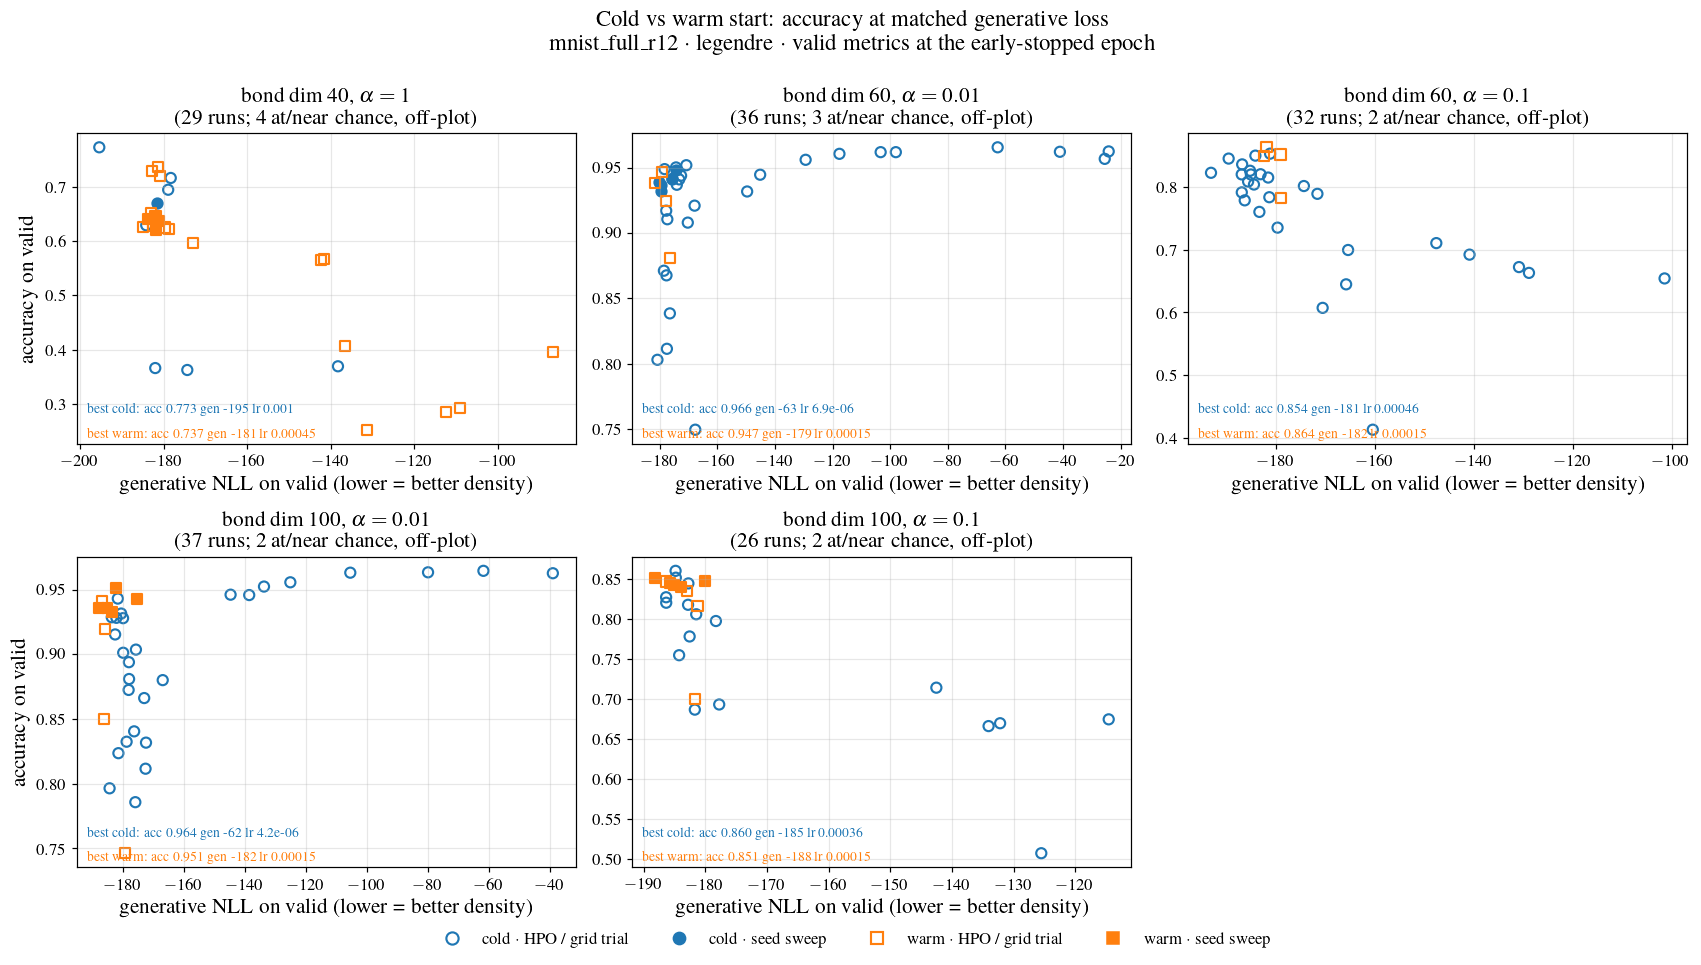

Saved figures/coldvswarm/cold_vs_warm_acc_vs_genloss.png


In [7]:
STAGE_STYLE = {"hpo": dict(marker="o", facecolors="none", s=42, linewidths=1.3),
               "seed_sweep": dict(marker="s", s=42, linewidths=1.3)}


def _panels(cells, ncols=3):
    nrows = int(np.ceil(len(cells) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[len(cells):]:
        ax.set_visible(False)
    return fig, axes


def _cell_scatter(ax, cell, xcol):
    for st, mk in (("cold", "o"), ("warm", "s")):
        for stage, sty in (("hpo", dict(facecolors="none")), ("seed_sweep", {})):
            d = cell[(cell.start == st) & cell.usable
                     & (cell.stage.fillna("hpo") == stage)]
            if d.empty:
                continue
            ax.scatter(d[xcol], d.sel_acc, marker=mk, s=44, linewidths=1.4,
                       edgecolors=START_COLOR[st],
                       color=START_COLOR[st] if not sty else "none", **sty)
    ax.grid(alpha=0.3)


LEGEND_HANDLES = [
    plt.Line2D([], [], ls="", marker="o", mfc="none", mec=START_COLOR["cold"], mew=1.4,
               ms=8, label=r"cold $\cdot$ HPO / grid trial"),
    plt.Line2D([], [], ls="", marker="o", color=START_COLOR["cold"], ms=8,
               label=r"cold $\cdot$ seed sweep"),
    plt.Line2D([], [], ls="", marker="s", mfc="none", mec=START_COLOR["warm"], mew=1.4,
               ms=8, label=r"warm $\cdot$ HPO / grid trial"),
    plt.Line2D([], [], ls="", marker="s", color=START_COLOR["warm"], ms=8,
               label=r"warm $\cdot$ seed sweep"),
]

fig, axes = _panels(CELLS)
for ax, (bd, a) in zip(axes, CELLS):
    cell = W[(W.bond_dim == bd) & (W.alpha == a)]
    _cell_scatter(ax, cell, "sel_gen_loss")
    n_off = int((~cell.usable).sum())
    ax.set_title(rf"bond dim {bd},  $\alpha = {a:g}$" + "\n"
                 + rf"({int(cell.usable.sum())} runs; {n_off} at/near chance, off-plot)")
    txt = []
    for st in ("cold", "warm"):
        r = SUMMARY[(SUMMARY.bond_dim == bd) & (SUMMARY.alpha == a)
                    & (SUMMARY.start == st)].iloc[0]
        txt.append((st, rf"best {st}:   acc {r.best_acc:.3f}   gen {r.gen_at_best_acc:.0f}"
                        rf"   lr {r.lr_at_best_acc:.2g}"))
    for i, (st, line) in enumerate(txt):
        ax.text(0.02, 0.10 - 0.08 * i, line, transform=ax.transAxes, fontsize=9,
                color=START_COLOR[st], family="monospace" if not USE_LATEX else None)
for ax in axes[:len(CELLS)]:
    ax.set_xlabel("generative NLL on valid   (lower = better density)")
for ax in axes[::3]:
    ax.set_ylabel("accuracy on valid")
fig.suptitle("Cold vs warm start: accuracy at matched generative loss\n"
             rf"{DATASET.replace('_', chr(92) + '_') if USE_LATEX else DATASET} "
             r"$\cdot$ " + EMBEDDING + r" $\cdot$ valid metrics at the early-stopped epoch",
             y=1.0, fontsize=15)
fig.legend(handles=LEGEND_HANDLES, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.tight_layout()
save(fig, CVW_ROOT / "cold_vs_warm_acc_vs_genloss.png")

### §1.2  The same runs against learning rate

The companion view. It is what separates "cold initialisation is better" from "the cold
grid simply searched a better learning rate" — at r40 $\alpha=1$ the whole cold advantage
sits at $\text{lr}=10^{-3}$, which the warm seed sweep never used.

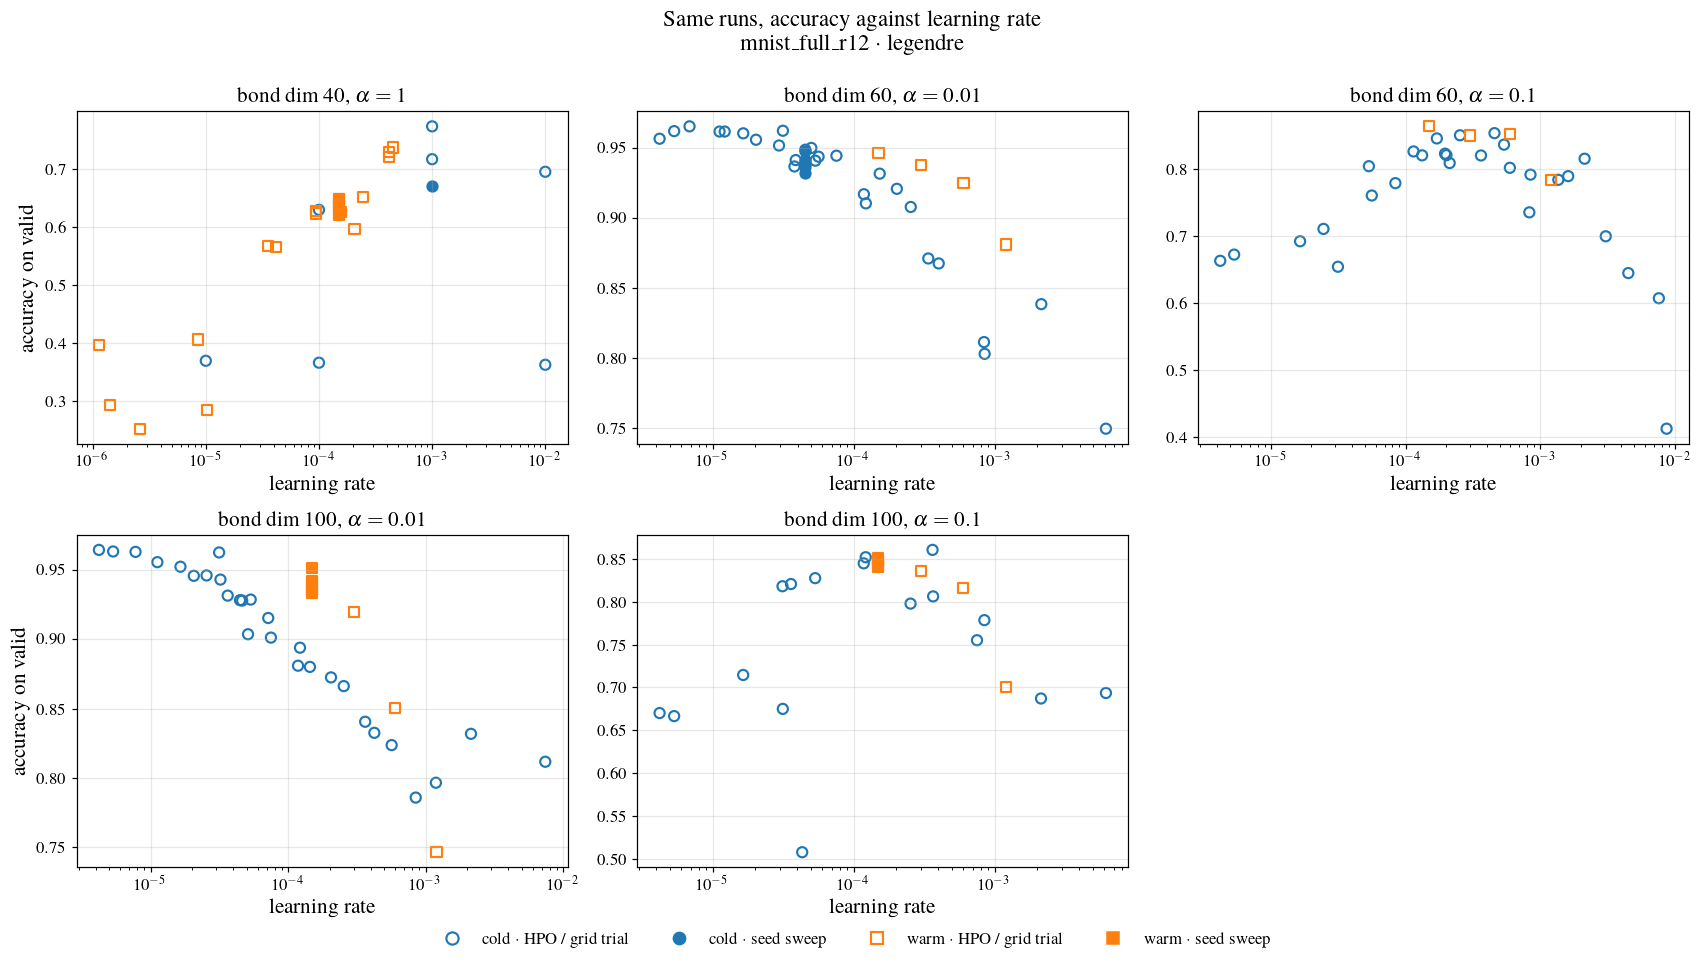

Saved figures/coldvswarm/cold_vs_warm_acc_vs_lr.png


In [8]:
fig, axes = _panels(CELLS)
for ax, (bd, a) in zip(axes, CELLS):
    _cell_scatter(ax, W[(W.bond_dim == bd) & (W.alpha == a)], "lr")
    ax.set_xscale("log")
    ax.set_title(rf"bond dim {bd},  $\alpha = {a:g}$")
for ax in axes[:len(CELLS)]:
    ax.set_xlabel("learning rate")
for ax in axes[::3]:
    ax.set_ylabel("accuracy on valid")
fig.suptitle("Same runs, accuracy against learning rate\n"
             + (DATASET.replace("_", chr(92) + "_") if USE_LATEX else DATASET)
             + r" $\cdot$ " + EMBEDDING, y=1.0, fontsize=15)
fig.legend(handles=LEGEND_HANDLES, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.tight_layout()
save(fig, CVW_ROOT / "cold_vs_warm_acc_vs_lr.png")

---
---
# Part 2 — one bond dimension, the full metric set

Everything below is `ARCH` only, from the local analysis CSVs, and lands in `FIG_DIR`.

## §2.0  What differs besides the initialisation

The two r20 ladders are **not** a clean initialisation-only contrast, and no figure below
should be read as if they were. The hyper-parameters come from the authored seed-sweep
YAMLs (`configs/experiments/.../seed_sweep/*.yaml`) — the runs themselves live on mathqi
and no local `.hydra/config.yaml` exists to read instead.

In [9]:
from omegaconf import OmegaConf

CFG_DIR = PROJECT_ROOT / "configs" / "experiments" / DATASET / "nat" / EMBEDDING / ARCH / "seed_sweep"
_TOKEN_OF = {v: k for k, v in ALPHA_TOKEN.items()}


def _cfg_path(start, alpha):
    """Authored config for a cell. Warm dirs predate the `warm_` rename, so both names try."""
    tok = _TOKEN_OF.get(alpha, f"a{alpha:g}".replace(".", ""))
    names = {"warm": [f"warm_{tok}.yaml", f"{tok}.yaml"],
             "cold": [f"cold_{tok}.yaml"], "base": [f"{tok}.yaml"]}[start]
    for n in names:
        if (CFG_DIR / n).exists():
            return CFG_DIR / n
    return None


rows = []
for r in sorted(RUNS, key=lambda r: (r["alpha"], r["start"])):
    p = _cfg_path(r["start"], r["alpha"])
    row = {"alpha": r["alpha"], "start": r["start"], "run_dir": r["dir"].name,
           "config": p.name if p else "(not found)"}
    if p is not None:
        c = OmegaConf.to_container(OmegaConf.load(p), resolve=False)
        n = (c.get("trainer") or {}).get("nll") or {}
        row |= {"lr": ((n.get("optimizer") or {}).get("kwargs") or {}).get("lr"),
                "batch_size": n.get("batch_size"), "max_epoch": n.get("max_epoch"),
                "patience": n.get("patience"), "stop_crit": n.get("stop_crit"),
                "soft_strength": (n.get("norm_control") or {}).get("soft_strength"),
                "log_target": (n.get("norm_control") or {}).get("log_target"),
                "model_path": "yes" if c.get("model_path") else "no"}
    rows.append(row)
HPARAMS = pd.DataFrame(rows)
HPARAMS.to_csv(FIG_DIR / "warm_vs_cold_hparams.csv", index=False)

print("Authored hyper-parameters (NOT a run record -- the config as committed):")
print(HPARAMS.to_string(index=False))
print(f"\nSaved {rel(FIG_DIR / 'warm_vs_cold_hparams.csv')}")

# Confounds, read off the table rather than asserted, so they stay true at another arch.
print("\nWhat else differs, per matched alpha (these are ladder differences, not "
      "initialisation effects in isolation):")
for a in PAIRED_ALPHAS:
    w = HPARAMS[(HPARAMS.alpha == a) & (HPARAMS.start == "warm")].iloc[0]
    c = HPARAMS[(HPARAMS.alpha == a) & (HPARAMS.start == "cold")].iloc[0]
    diffs = [f"{k}: warm {w[k]!s} vs cold {c[k]!s}"
             for k in ("lr", "batch_size", "soft_strength", "log_target", "max_epoch",
                       "stop_crit")
             if str(w[k]) != str(c[k])]
    n_w = int(COVERAGE[(COVERAGE.alpha == a) & (COVERAGE.start == "warm")].n_eval.iloc[0])
    n_c = int(COVERAGE[(COVERAGE.alpha == a) & (COVERAGE.start == "cold")].n_eval.iloc[0])
    print(f"  alpha={a:g}  seeds {n_w} warm vs {n_c} cold")
    for d in diffs:
        print(f"      {d}")
print("""
Two things the table cannot tell you, worth checking in the config headers before quoting
any of this as an initialisation effect:
  - whether the cold HPs came from an HPO at THIS bond dim or were transferred from another
    one (at mnist r20 they were transferred from the r40/r60/r100 cold grids -- see the
    header of configs/experiments/.../seed_sweep/cold_a1.yaml);
  - that batch size travels with the transferred lr, so the two move together by design.""")

Authored hyper-parameters (NOT a run record -- the config as committed):
 alpha start         run_dir          config       lr  batch_size  max_epoch  patience  stop_crit  soft_strength                   log_target model_path
 0.000  base         a0_2406         a0.yaml 0.000235         512        300        60        acc   1.274900e-02 n_features * log(in_dim) / 2         no
 0.001  cold cold_a0001_3007 cold_a0001.yaml 0.000100         256        150        50 mixed_loss   1.000000e-03                          0.0         no
 0.010  cold  cold_a001_3007  cold_a001.yaml 0.000045         256        150        50 mixed_loss   7.801786e-07                          0.0         no
 0.010  warm       a001_2007  warm_a001.yaml 0.000452         512        100        50 mixed_loss   2.040805e-06                         None        yes
 0.100  cold   cold_a01_3007   cold_a01.yaml 0.000250         256        150        50 mixed_loss   1.000000e-03                          0.0         no
 0.100  w

## §2.1  The whole ladder, six metrics

Mean $\pm$ 1 std over seeds, warm against cold, at $\varepsilon = $ `EPS_MAIN`
(shown in `REPORT_UNIT`). The grey star is the shared $\alpha=0$ base — the checkpoint the
warm ladder fine-tunes *from*, and a cold-start run in its own right, so it belongs to
neither line.

| panel | column | reads as |
|---|---|---|
| Clean accuracy | `acc` | classification, no attack |
| Robust accuracy | `rob/{eps}` | PGD, no defense |
| Purified (likelihood) | `uq_purify_acc/{eps}/{delta}` | gradient purification inside a $\delta$-ball |
| Purified (Gibbs) | `gibbs_purify_acc/{eps}/{k}` | $k$ Gibbs sweeps; 250-sample subsample, so ~$\pm$3% extra noise |
| Generative NLL | `gen_loss` | lower = better density |
| Detection rate | `uq_detection/{q}/{eps}` | fraction of adversarial inputs whose $\log p(x)$ falls below the $q$-th clean percentile |

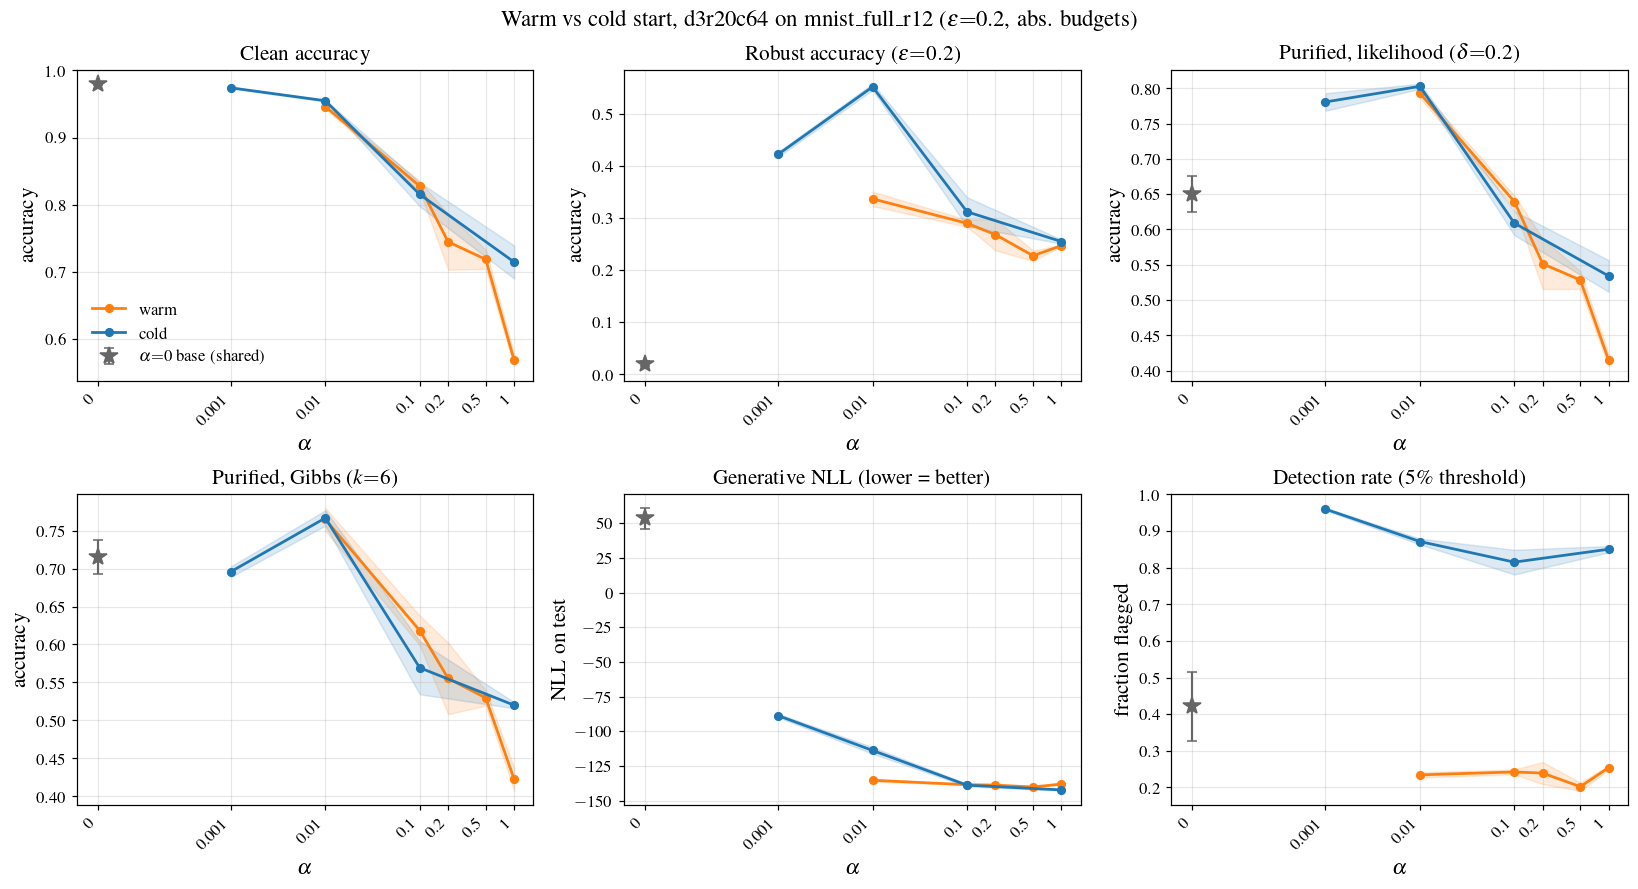

Saved figures/coldvswarm/legendre/d3r20c64/alpha_ladder_warm_vs_cold.png


In [10]:
PANELS = [
    ("Clean accuracy", EVAL, "acc", None),
    (rf"Robust accuracy ($\varepsilon{{=}}{EPS_MAIN_D}$)", EVAL, f"rob/{EPS_MAIN}", None),
    (rf"Purified, likelihood ($\delta{{=}}{PURIFY_RADIUS_D}$)", EVAL,
     f"uq_purify_acc/{EPS_MAIN}/{PURIFY_RADIUS}", None),
    (rf"Purified, Gibbs ($k{{=}}{GIBBS_K}$)", GIBBS,
     f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}", None),
    ("Generative NLL (lower = better)", EVAL, "gen_loss", "nll"),
    (rf"Detection rate ({DET_PCT[:-3]}{PCT} threshold)", EVAL,
     f"uq_detection/{DET_PCT}/{EPS_MAIN}", None),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.2))
for ax, (title, df, col, kind) in zip(axes.ravel(), PANELS):
    for st in ("warm", "cold"):
        errline(ax, *ladder(df, col, st), color=START_COLOR[st], label=START_LABEL[st])
    base_marker(ax, df, col)
    setup_alpha_axis(ax)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    if kind != "nll":
        ax.set_ylabel("accuracy" if "Detection" not in title else "fraction flagged")
    else:
        ax.set_ylabel("NLL on test")
axes[0, 0].legend(frameon=False, loc="best")
fig.suptitle(rf"Warm vs cold start, {ARCH} on "
             + (DATASET.replace("_", chr(92) + "_") if USE_LATEX else DATASET)
             + rf" ($\varepsilon{{=}}{EPS_MAIN_D}$, {REPORT_UNIT}. budgets)", fontsize=15)
fig.tight_layout()
save(fig, FIG_DIR / "alpha_ladder_warm_vs_cold.png")

## §2.2  Every accuracy metric, at the matched $\alpha$

The same test set under five different threat/defense settings, warm against cold, only
where both ladders have the $\alpha$. `joint` is the attacker who also sees the defense
(`uq_joint_adv_acc`) — the honest number for a purification defense.

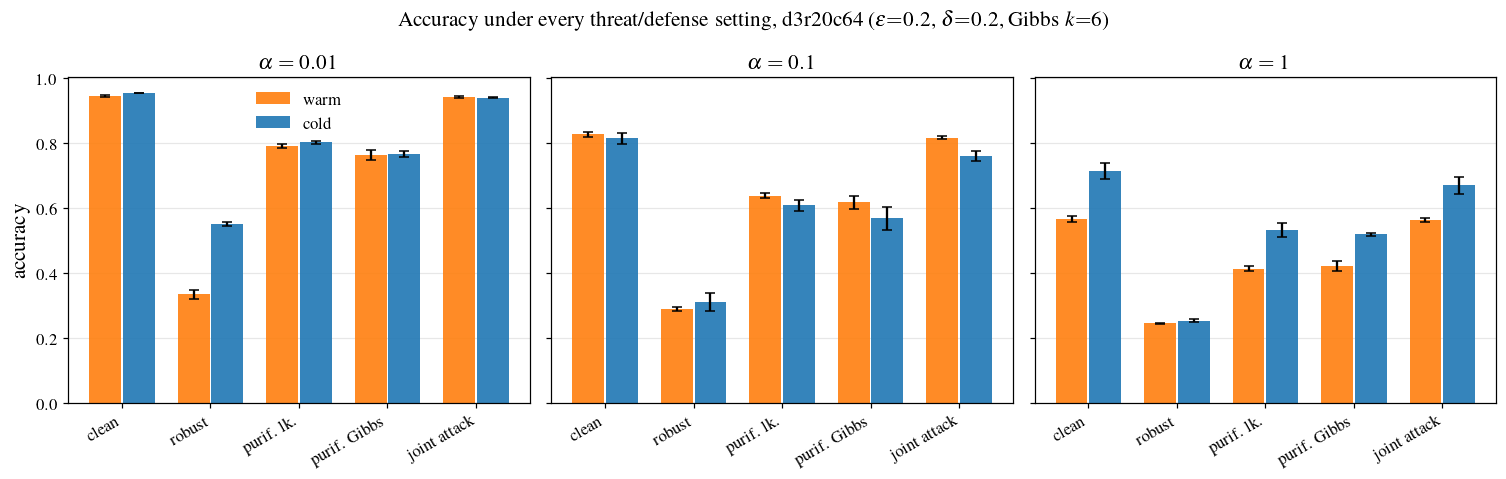

Saved figures/coldvswarm/legendre/d3r20c64/accuracy_metrics_warm_vs_cold.png


In [11]:
BAR_METRICS = [
    ("clean", EVAL, "acc"),
    (rf"robust", EVAL, f"rob/{EPS_MAIN}"),
    (rf"purif. lk.", EVAL, f"uq_purify_acc/{EPS_MAIN}/{PURIFY_RADIUS}"),
    (rf"purif. Gibbs", GIBBS, f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}"),
    (rf"joint attack", EVAL, f"uq_joint_adv_acc/{EPS_MAIN}"),
]

if not PAIRED_ALPHAS:
    print(f"{ARCH}: no alpha has both ladders -- nothing to pair, figure skipped.")
else:
    fig, axes = plt.subplots(1, len(PAIRED_ALPHAS),
                             figsize=(4.6 * len(PAIRED_ALPHAS), 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(BAR_METRICS))
    for ax, a in zip(axes, PAIRED_ALPHAS):
        for i, st in enumerate(("warm", "cold")):
            mm = [ms(sel(df, st, a), col)[0] for _, df, col in BAR_METRICS]
            sd = [ms(sel(df, st, a), col)[1] for _, df, col in BAR_METRICS]
            ax.bar(x + (i - 0.5) * 0.38, mm, 0.36, yerr=np.nan_to_num(sd), capsize=3,
                   color=START_COLOR[st], label=START_LABEL[st], alpha=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels([m[0] for m in BAR_METRICS], rotation=30, ha="right")
        ax.set_title(rf"$\alpha = {a:g}$")
        ax.grid(alpha=0.3, axis="y")
        ax.set_axisbelow(True)
    axes[0].set_ylabel("accuracy")
    axes[0].legend(frameon=False)
    fig.suptitle(rf"Accuracy under every threat/defense setting, {ARCH}   "
                 rf"($\varepsilon{{=}}{EPS_MAIN_D}$, $\delta{{=}}{PURIFY_RADIUS_D}$, "
                 rf"Gibbs $k{{=}}{GIBBS_K}$)", fontsize=14)
    fig.tight_layout()
    save(fig, FIG_DIR / "accuracy_metrics_warm_vs_cold.png")

## §2.3  The trade-off plane, per seed

Part 1's axes at run level for this bond dimension: every seed as a point, accuracy against
generative NLL, with each ladder's per-$\alpha$ means joined in $\alpha$ order. Up and to the
left is better on both axes. This is the figure that says whether a ladder wins outright or
only trades one axis for the other.

The $\alpha=0$ base is **off this plot on purpose** — it is a discriminative model whose
generative NLL is positive (printed below), two orders of magnitude away from the ladders,
and plotting it flattens everything else onto the left edge. It is in §2.1 and both CSVs.

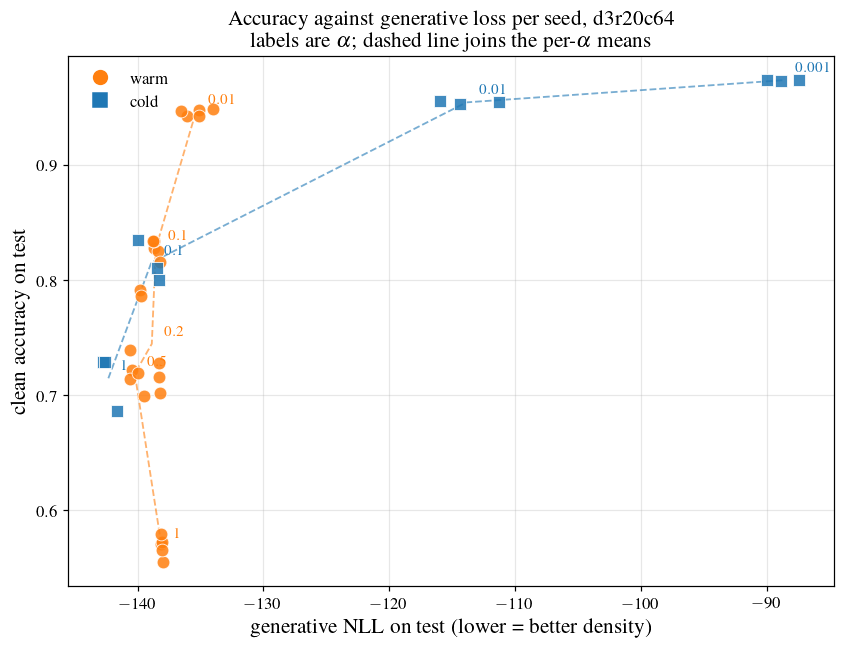

Saved figures/coldvswarm/legendre/d3r20c64/acc_vs_genloss_warm_vs_cold.png
alpha=0 base (off-plot): gen_loss +53.5 +/- 7.6, acc 0.9793 +/- 0.0010


In [12]:
MARK = {"warm": "o", "cold": "s"}

fig, ax = plt.subplots(figsize=(7.8, 6))
for st in ("warm", "cold"):
    gm, am = [], []
    for a in sorted(set(sel(EVAL, st)["alpha"])):
        d = sel(EVAL, st, a)
        ax.scatter(d["gen_loss"], d["acc"], s=70, marker=MARK[st], color=START_COLOR[st],
                   alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
        gm.append(d["gen_loss"].mean()); am.append(d["acc"].mean())
        ax.annotate(rf"${a:g}$", (gm[-1], am[-1]), textcoords="offset points",
                    xytext=(8, 6), fontsize=10, color=START_COLOR[st])
    ax.plot(gm, am, color=START_COLOR[st], lw=1.2, ls="--", alpha=0.6, zorder=2)

_bg, _ba, _ = ms(sel(EVAL, "base"), "gen_loss"), ms(sel(EVAL, "base"), "acc"), None
ax.set_xlabel("generative NLL on test   (lower = better density)")
ax.set_ylabel("clean accuracy on test")
ax.grid(alpha=0.3)
ax.legend(handles=[plt.Line2D([], [], ls="", marker=MARK[s], color=START_COLOR[s], ms=9,
                              label=START_LABEL[s]) for s in ("warm", "cold")],
          frameon=False, loc="best")
ax.set_title(rf"Accuracy against generative loss per seed, {ARCH}" + "\n"
             + r"labels are $\alpha$; dashed line joins the per-$\alpha$ means")
fig.tight_layout()
save(fig, FIG_DIR / "acc_vs_genloss_warm_vs_cold.png")
print(f"alpha=0 base (off-plot): gen_loss {_bg[0]:+.1f} +/- {_bg[1]:.1f}, "
      f"acc {_ba[0]:.4f} +/- {_ba[1]:.4f}")

## §2.4  Decay with the attack budget

Whether a gap at the headline budget is a level shift or a different decay. Solid =
undefended PGD, dashed = likelihood purification at $\delta = $ `PURIFY_RADIUS`. The
$\varepsilon = 0$ points are the clean accuracy and the clean-input purified accuracy
(what the defense costs when nothing attacked).

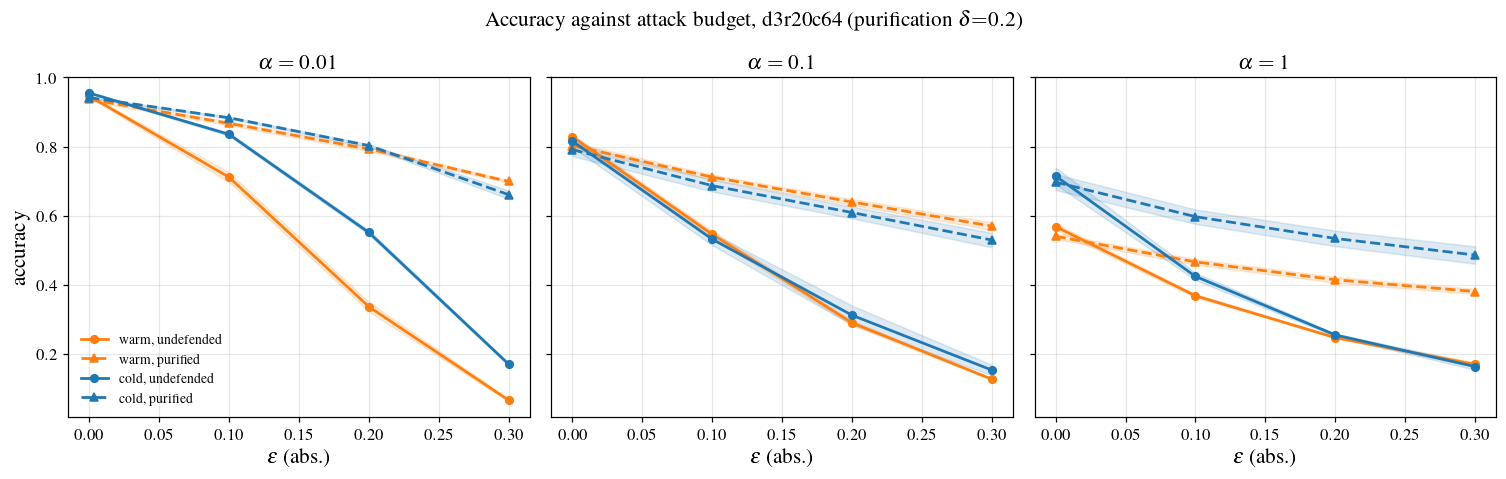

Saved figures/coldvswarm/legendre/d3r20c64/acc_vs_eps_warm_vs_cold.png


In [13]:
EPS_AXIS = [0.0] + EPS_LIST


def eps_curve(st, a, defended):
    xs, mm, ss = [], [], []
    for e in EPS_AXIS:
        if defended:
            col = (f"uq_clean_purify_acc/{PURIFY_RADIUS}" if e == 0
                   else f"uq_purify_acc/{e}/{PURIFY_RADIUS}")
        else:
            col = "acc" if e == 0 else f"rob/{e}"
        m, s, n = ms(sel(EVAL, st, a), col)
        if n:
            xs.append(float(bstr(e))); mm.append(m); ss.append(s)
    return np.array(xs), np.array(mm), np.nan_to_num(np.array(ss))


if not PAIRED_ALPHAS:
    print(f"{ARCH}: no alpha has both ladders -- nothing to pair, figure skipped.")
else:
    fig, axes = plt.subplots(1, len(PAIRED_ALPHAS),
                             figsize=(4.6 * len(PAIRED_ALPHAS), 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, a in zip(axes, PAIRED_ALPHAS):
        for st in ("warm", "cold"):
            errline(ax, *eps_curve(st, a, False), color=START_COLOR[st],
                    label=f"{START_LABEL[st]}, undefended")
            errline(ax, *eps_curve(st, a, True), color=START_COLOR[st], ls="--",
                    marker="^", label=rf"{START_LABEL[st]}, purified")
        ax.set_title(rf"$\alpha = {a:g}$")
        ax.set_xlabel(rf"$\varepsilon$ ({REPORT_UNIT}.)")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("accuracy")
    axes[0].legend(frameon=False, fontsize=9)
    fig.suptitle(rf"Accuracy against attack budget, {ARCH}   "
                 rf"(purification $\delta{{=}}{PURIFY_RADIUS_D}$)", fontsize=14)
    fig.tight_layout()
    save(fig, FIG_DIR / "acc_vs_eps_warm_vs_cold.png")

## §2.5  Tables

- **`warm_vs_cold_summary.csv`** — mean and std over seeds for every metric, one row per
  $(\alpha, \text{start})$.
- **`warm_vs_cold_delta.csv`** — cold minus warm at the matched $\alpha$, with the standard
  error of the difference and both seed counts, so the imbalance travels with the number.
  With 3 vs 5 seeds these are effect sizes, not significance tests.

In [14]:
METRICS = ([(EVAL, "acc"), (EVAL, "dis_loss"), (EVAL, "gen_loss"),
            (EVAL, "uq_clean_log_px_mean"), (EVAL, f"uq_clean_purify_acc/{PURIFY_RADIUS}")]
           + [(EVAL, f"rob/{e}") for e in EPS_LIST]
           + [(EVAL, f"uq_purify_acc/{e}/{PURIFY_RADIUS}") for e in EPS_LIST]
           + [(EVAL, f"uq_joint_adv_acc/{e}") for e in EPS_LIST]
           + [(EVAL, f"uq_detection/{DET_PCT}/{e}") for e in EPS_LIST]
           + [(GIBBS, "gibbs_clean_acc"), (GIBBS, f"gibbs_clean_purify_acc/{GIBBS_K}")]
           + [(GIBBS, f"gibbs_purify_acc/{e}/{GIBBS_K}") for e in EPS_LIST])

rows = []
for st in ("base", "warm", "cold"):
    for a in sorted(set(sel(EVAL, st)["alpha"])):
        row = {"alpha": a, "start": st,
               "run_dir": sel(EVAL, st, a)["run_dir"].iloc[0],
               "n_eval": ms(sel(EVAL, st, a), "acc")[2],
               "n_gibbs": ms(sel(GIBBS, st, a), "gibbs_clean_acc")[2]}
        for df, col in METRICS:
            m, s, _ = ms(sel(df, st, a), col)
            row[f"{col}_mean"], row[f"{col}_std"] = m, s
        rows.append(row)
SUMMARY_R = pd.DataFrame(rows).sort_values(["alpha", "start"]).reset_index(drop=True)
SUMMARY_R.to_csv(FIG_DIR / "warm_vs_cold_summary.csv", index=False)

rows = []
for a in PAIRED_ALPHAS:
    for df, col in METRICS:
        wm, ws, wn = ms(sel(df, "warm", a), col)
        cm, cs, cn = ms(sel(df, "cold", a), col)
        if not wn or not cn:
            continue
        se = float(np.sqrt((ws ** 2) / max(wn, 1) + (cs ** 2) / max(cn, 1)))
        rows.append({"alpha": a, "metric": col, "warm_mean": wm, "warm_std": ws,
                     "cold_mean": cm, "cold_std": cs, "delta_cold_minus_warm": cm - wm,
                     "se_delta": se, "n_warm": wn, "n_cold": cn})
DELTA = pd.DataFrame(rows)
print(f"Saved {rel(FIG_DIR / 'warm_vs_cold_summary.csv')}  "
      f"({SUMMARY_R.shape[0]} rows x {SUMMARY_R.shape[1]} cols)")
if DELTA.empty:
    print("no matched alpha -- warm_vs_cold_delta.csv not written")
else:
    DELTA.to_csv(FIG_DIR / "warm_vs_cold_delta.csv", index=False)
    print(f"Saved {rel(FIG_DIR / 'warm_vs_cold_delta.csv')}  ({DELTA.shape[0]} rows)")
print()

_head = ["acc", "gen_loss", f"rob/{EPS_MAIN}",
         f"uq_purify_acc/{EPS_MAIN}/{PURIFY_RADIUS}",
         f"gibbs_purify_acc/{EPS_MAIN}/{GIBBS_K}",
         f"uq_joint_adv_acc/{EPS_MAIN}", f"uq_detection/{DET_PCT}/{EPS_MAIN}"]
if DELTA.empty:
    print(f"{ARCH}: no matched alpha, so no delta table.")
else:
    print("cold - warm at the matched alphas (positive = cold better, except gen_loss):")
    print(DELTA[DELTA.metric.isin(_head)]
          .pivot(index="metric", columns="alpha", values="delta_cold_minus_warm")
          .reindex(_head).round(4).to_string())

Saved figures/coldvswarm/legendre/d3r20c64/warm_vs_cold_summary.csv  (10 rows x 49 cols)
Saved figures/coldvswarm/legendre/d3r20c64/warm_vs_cold_delta.csv  (66 rows)

cold - warm at the matched alphas (positive = cold better, except gen_loss):
alpha                      0.01    0.10    1.00
metric                                         
acc                      0.0087 -0.0123  0.1464
gen_loss                21.5048 -0.3493 -4.2301
rob/0.1                  0.2148  0.0220  0.0078
uq_purify_acc/0.1/0.1    0.0100 -0.0305  0.1196
gibbs_purify_acc/0.1/6   0.0019 -0.0491  0.0976
uq_joint_adv_acc/0.1    -0.0008 -0.0569  0.1082
uq_detection/5pct/0.1    0.6374  0.5730  0.5964


---
## §2.6  What the numbers say

**Snapshot of the default configuration** (`mnist_full_r12`, `d3r20c64`, runs analysed as of
2026-08-02). Re-run at another arch and the figures update but this text does not.

1. **$\alpha=1$ is where the ladders genuinely part.** Cold reaches clean accuracy
   $0.715 \pm 0.025$ against warm's $0.568 \pm 0.009$ — and it does so at a *lower*
   generative NLL ($-142.3$ vs $-138.1$). That is a win on both axes, not a trade, and it
   repeats the r40 $\alpha=1$ result of Part 1 ($0.773$ @ $-195$ cold vs $0.737$ @ $-181$
   warm) one bond dimension down. Part 1's caveat transfers with it: the warm r20 $\alpha=1$
   run learns at lr $9.5\times10^{-5}$ against cold's $10^{-3}$, so "cold start" and "ten
   times the learning rate" are not separated by this experiment.
2. **$\alpha=0.01$ is a trade, not a win.** Cold is ahead on clean accuracy ($+0.009$) and
   far ahead on undefended robustness ($+0.215$) — but its density is **21.5 nats worse**
   ($-113.9$ vs $-135.4$). Its lr is $10\times$ *lower* than warm's here, the opposite of
   the $\alpha=1$ direction, which is consistent with the cold run simply having travelled
   less far. Do not read the robustness gap at this $\alpha$ as an initialisation effect.
3. **$\alpha=0.1$ is a wash on accuracy and a wash on density** — every accuracy metric is
   within $\pm0.06$ and the two generative losses within $0.35$ nats. This is the one cell
   where the ladders are close enough to compare cleanly, and there is nothing to choose.
4. **Detection is the one difference that holds at every $\alpha$ and is not explained by
   generative loss.** At the 5% threshold, cold flags $0.82$–$0.96$ of adversarial inputs;
   warm flags $0.20$–$0.25$ — a gap of $+0.57$ to $+0.64$, including at $\alpha=1$ where the
   two densities are within 4 nats of each other. Something about the warm $\log p(x)$
   surface makes adversarial inputs *not* look unlikely, and it survives fine-tuning to
   equal density. This is the finding worth chasing.

Everything above is a **ladder** difference. Per §2.0 the two ladders also differ in learning
rate, batch size, soft-norm strength and epoch budget, and the cold HPs at this bond dimension
were transferred rather than tuned here — so none of these is an initialisation effect in
isolation. Separating them needs a matched-HP run, not another reading of this table.